Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)                   │ (None, 8, 32)               │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_10 (MaxPooling1D)      │ (None, 4, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_11 (Conv1D)                   │ (None, 2, 64)               │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_11 (MaxPooling1D)      │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 1, 128)              │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 1, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 105,665 (412.75 KB)

 Trainable params: 105,665 (412.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.2490 - mae: 0.4174 - val_loss: 0.1019 - val_mae: 0.2673
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1011 - mae: 0.2671 - val_loss: 0.0871 - val_mae: 0.2520
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0912 - mae: 0.2582 - val_loss: 0.0836 - val_mae: 0.2480
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0857 - mae: 0.2514 - val_loss: 0.0835 - val_mae: 0.2480
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0861 - mae: 0.2540 - val_loss: 0.0834 - val_mae: 0.2480
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0839 - mae: 0.2494 - val_loss: 0.0835 - val_mae: 0.2480
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0864 - mae: 0.2547 - val_loss: 0.0835 - val_mae: 0.2480
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0842 - mae: 0.2501 - val_loss: 0.0836 - val_mae: 0.2480
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.085

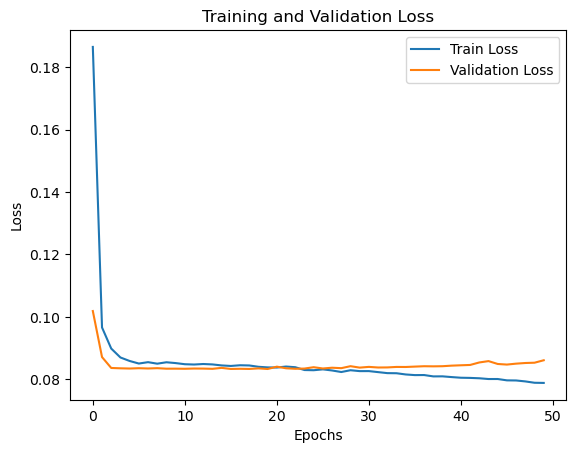

Test Loss: 0.08728866279125214
Test MAE: 0.25623276829719543
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


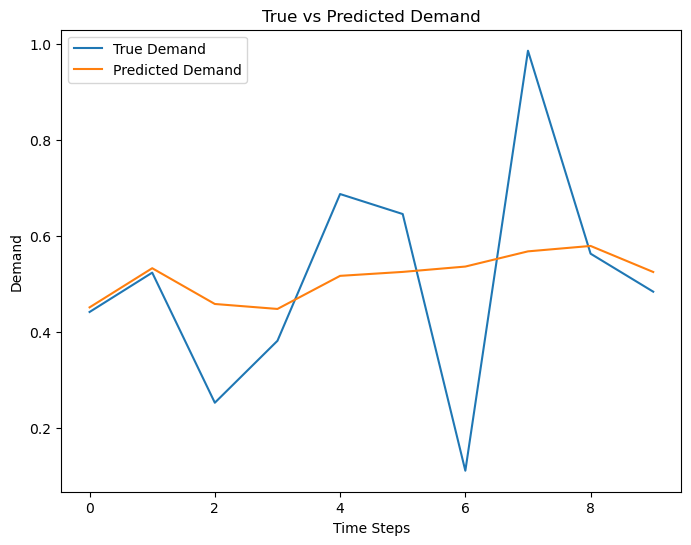

In [7]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input

# 设置随机种子以保证实验结果的可重复性
np.random.seed(42)

# 生成模拟数据
def generate_data(num_samples=1000, seq_len=10, num_features=5):
    """ 生成随机交通流量和需求数据 """
    X = np.random.rand(num_samples, seq_len, num_features)  # 交通数据（如路况，车速等）
    y = np.random.rand(num_samples, seq_len, 1)  # 运输需求（每个时间点的货物需求量）
    return X, y

# 生成数据
num_samples = 1000
seq_len = 10  # 每个样本的时间序列长度
num_features = 5  # 输入特征数（如交通流量，路段信息等）
X, y = generate_data(num_samples, seq_len, num_features)

# 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 拆分数据集：70%训练集，20%验证集，10%测试集
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# 构建CNN-LSTM模型
def build_cnn_lstm_model(input_shape):
    """ 构建基于CNN-LSTM的模型 """
    model = Sequential()

    # 输入层
    model.add(Input(shape=input_shape))

    # CNN层（用于提取空间特征）
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))

    # LSTM层（用于时间序列建模）
    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.2))

    # 输出层
    model.add(Flatten())
    model.add(Dense(units=1))

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# 模型输入形状（样本数量，时间步长，特征数量）
input_shape = (seq_len, num_features)
model = build_cnn_lstm_model(input_shape)

# 模型概述
model.summary()

# 训练模型
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

# 绘制训练过程中的损失曲线
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 评估模型
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print(f'Test Loss: {test_loss}')
print(f'Test MAE: {test_mae}')

# 使用模型进行预测
y_pred = model.predict(X_test)

# 修复反标准化，确保维度正确
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# 将 y_pred 调整为与 y_test 对齐的维度（只考虑第一个时间步）
y_pred_rescaled = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).reshape(-1, 1)

# 确保绘图时 x 和 y 长度一致
plt.figure(figsize=(8, 6))
time_steps = range(len(y_test_rescaled[0]))  # 时间步长度

# 绘制真实值
plt.plot(time_steps, y_test_rescaled[0].flatten(), label='True Demand')

# 绘制预测值（取前几个时间步，长度需匹配）
plt.plot(time_steps, y_pred_rescaled.flatten()[:len(time_steps)], label='Predicted Demand')

plt.legend()
plt.title('True vs Predicted Demand')
plt.xlabel('Time Steps')
plt.ylabel('Demand')
plt.show()



C:\Users\l\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_14 (Conv1D)                   │ (None, 10, 64)              │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_14 (MaxPooling1D)      │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_15 (Conv1D)                   │ (None, 5, 128)              │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_15 (MaxPooling1D)      │ (None, 2, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_8 (LSTM)                        │ (None, 2, 128)              │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 2, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_9 (LSTM)                        │ (None, 2, 64)               │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 2, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_7 (Flatten)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 215,041 (840.00 KB)

 Trainable params: 215,041 (840.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.2366 - mae: 0.4036 - val_loss: 0.0968 - val_mae: 0.2623 - learning_rate: 0.0010
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0932 - mae: 0.2602 - val_loss: 0.0843 - val_mae: 0.2491 - learning_rate: 0.0010
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0872 - mae: 0.2539 - val_loss: 0.0830 - val_mae: 0.2477 - learning_rate: 0.0010
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0863 - mae: 0.2540 - val_loss: 0.0831 - val_mae: 0.2478 - learning_rate: 0.0010
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0868 - mae: 0.2541 - val_loss: 0.0829 - val_mae: 0.2475 - learning_rate: 0.0010
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0861 - mae: 0.2532 - val_loss: 0.0837 - val_mae: 0.2485 - learning_rate: 0.0010
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0869 - mae: 0.2547 - val_loss: 0.0830 - val_mae: 0.2477 - learning_rate: 0.0010
Epoch 

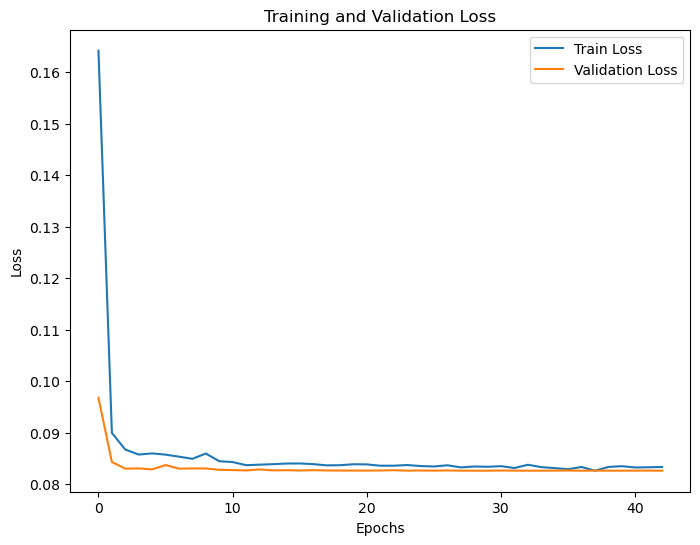

Test Loss: 0.0833
Test MAE: 0.2509
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step


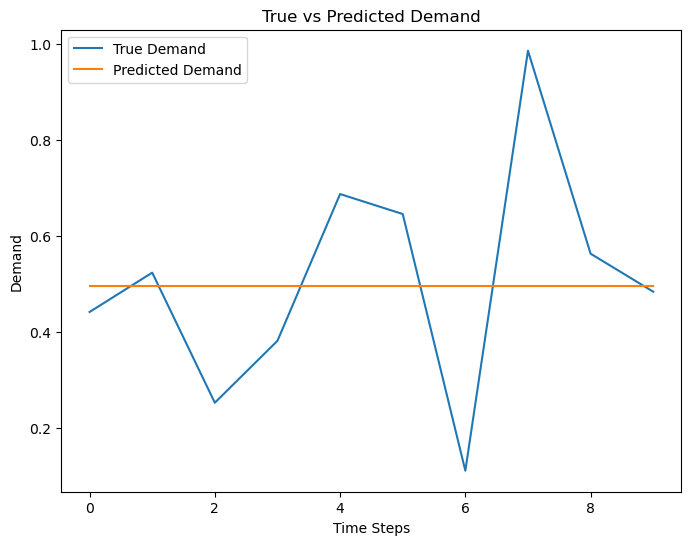

In [9]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 设置随机种子以保证实验结果的可重复性
np.random.seed(42)

# 生成模拟数据
def generate_data(num_samples=1000, seq_len=10, num_features=5):
    """生成随机交通流量和需求数据"""
    X = np.random.rand(num_samples, seq_len, num_features)  # 输入特征
    y = np.random.rand(num_samples, seq_len, 1)            # 目标值（需求量）
    return X, y

# 数据生成
num_samples = 1000
seq_len = 10  # 每个样本的时间步长
num_features = 5  # 输入特征数
X, y = generate_data(num_samples, seq_len, num_features)

# 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 拆分数据集：70%训练集，20%验证集，10%测试集
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# 改进后的CNN-LSTM模型
def build_improved_cnn_lstm_model(input_shape):
    """改进版的CNN-LSTM模型"""
    model = Sequential()
    
    # CNN层：增加滤波器数量和层数
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    
    # LSTM层：增加单元数量
    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.3))
    
    # Dense层：增加全连接层
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# 模型输入形状
input_shape = (seq_len, num_features)
model = build_improved_cnn_lstm_model(input_shape)

# 模型概述
model.summary()

# 设置回调函数：早停法和学习率调节
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# 训练模型
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 绘制训练过程中的损失曲线
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 评估模型
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test MAE: {test_mae:.4f}')

# 使用模型进行预测
y_pred = model.predict(X_test)

# 修复反标准化
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# 由于 y_pred 是 (samples, 1)，扩展 y_pred 到与 y_test 的形状匹配
y_pred_rescaled = scaler_y.inverse_transform(y_pred.reshape(-1, 1))

# 绘制预测结果与实际值的对比（只比较第一个时间序列样本）
plt.figure(figsize=(8, 6))
time_steps = range(y_test.shape[1])  # 取时间步数
plt.plot(time_steps, y_test_rescaled[0].flatten(), label='True Demand')
plt.plot(time_steps, [y_pred_rescaled[0]] * len(time_steps), label='Predicted Demand')  # 重复预测值
plt.legend()
plt.title('True vs Predicted Demand')
plt.xlabel('Time Steps')
plt.ylabel('Demand')
plt.show()



Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.2316 - mae: 0.3969 - val_loss: 0.0912 - val_mae: 0.2565 - learning_rate: 0.0010
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0902 - mae: 0.2569 - val_loss: 0.0836 - val_mae: 0.2483 - learning_rate: 0.0010
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0875 - mae: 0.2544 - val_loss: 0.0829 - val_mae: 0.2476 - learning_rate: 0.0010
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0866 - mae: 0.2542 - val_loss: 0.0829 - val_mae: 0.2476 - learning_rate: 0.0010
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0861 - mae: 0.2527 - val_loss: 0.0827 - val_mae: 0.2474 - learning_rate: 0.0010
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0856 - mae: 0.2533 - val_loss: 0.0827 - val_mae: 0.2474 - learning_rate: 0.0010
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0869 - mae: 0.2557 - val_loss: 0.0829 - val_mae: 0.2475 - learning_rate: 0.0010
Epoch 

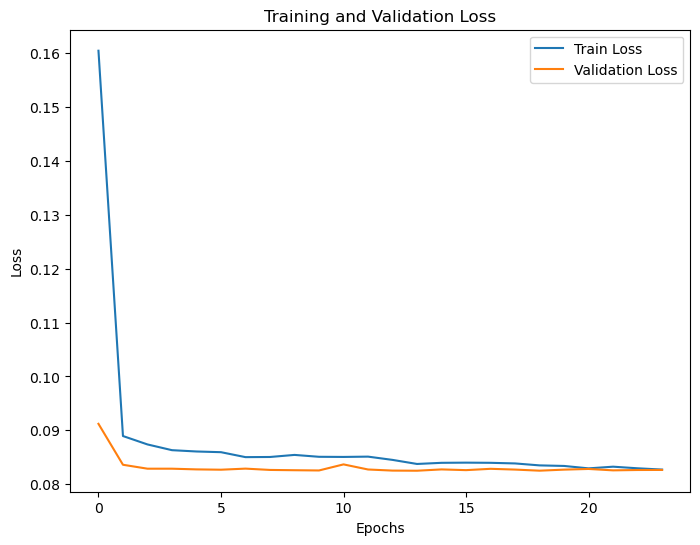

Test Loss: 0.0833
Test MAE: 0.2510
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step


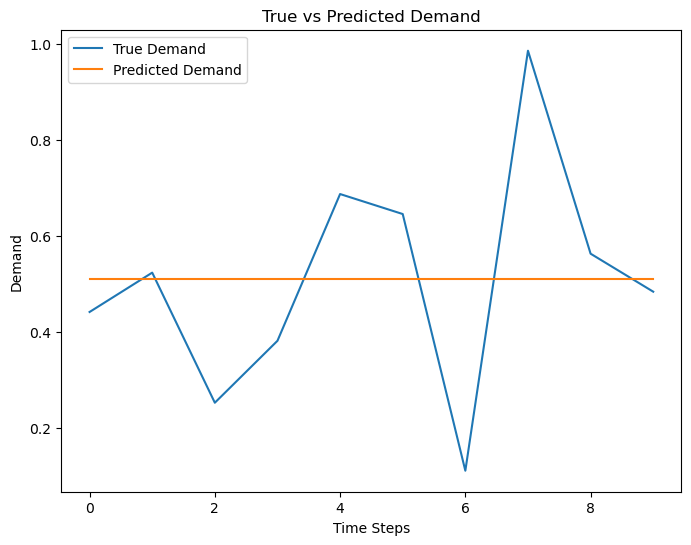

In [10]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 设置随机种子
np.random.seed(42)

# 1. 生成模拟数据
def generate_data(num_samples=1000, seq_len=10, num_features=5):
    """生成随机交通流量和需求数据"""
    X = np.random.rand(num_samples, seq_len, num_features)  # 输入特征
    y = np.random.rand(num_samples, seq_len, 1)            # 目标值（需求量）
    return X, y

num_samples = 1000
seq_len = 10
num_features = 5
X, y = generate_data(num_samples, seq_len, num_features)

# 2. 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 3. 数据集划分：70%训练集，20%验证集，10%测试集
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# 4. 构建改进的CNN-LSTM模型
def build_improved_cnn_lstm_model(input_shape):
    """构建CNN-LSTM模型"""
    model = Sequential()
    model.add(Input(shape=input_shape))  # 使用 Input 层替代 input_shape
    
    # CNN层
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    
    # LSTM层
    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=False))
    model.add(Dropout(0.3))
    
    # Dense层
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (seq_len, num_features)
model = build_improved_cnn_lstm_model(input_shape)

# 5. 模型训练
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 6. 绘制训练过程的损失曲线
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 7. 模型评估
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test MAE: {test_mae:.4f}')

# 8. 预测结果与实际值对比
y_pred = model.predict(X_test)

# 反标准化
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
y_pred_rescaled = scaler_y.inverse_transform(y_pred.reshape(-1, 1))

# 绘制第一个样本的预测结果与实际值
plt.figure(figsize=(8, 6))
time_steps = range(len(y_test_rescaled[0]))
plt.plot(time_steps, y_test_rescaled[0].flatten(), label='True Demand')
plt.plot(time_steps, [y_pred_rescaled[0][0]] * len(time_steps), label='Predicted Demand')
plt.title('True vs Predicted Demand')
plt.xlabel('Time Steps')
plt.ylabel('Demand')
plt.legend()
plt.show()


Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.2451 - mae: 0.4539 - val_loss: 0.0295 - val_mae: 0.1392 - learning_rate: 0.0010
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0368 - mae: 0.1516 - val_loss: 0.0044 - val_mae: 0.0530 - learning_rate: 0.0010
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0248 - mae: 0.1252 - val_loss: 0.0046 - val_mae: 0.0543 - learning_rate: 0.0010
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0202 - mae: 0.1125 - val_loss: 0.0041 - val_mae: 0.0508 - learning_rate: 0.0010
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0168 - mae: 0.1031 - val_loss: 0.0040 - val_mae: 0.0508 - learning_rate: 0.0010
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0161 - mae: 0.0998 - val_loss: 0.0040 - val_mae: 0.0505 - learning_rate: 0.0010
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0154 - mae: 0.0992 - val_loss: 0.0040 - val_mae: 0.0506 - learning_rate: 0.0010
Epoch 

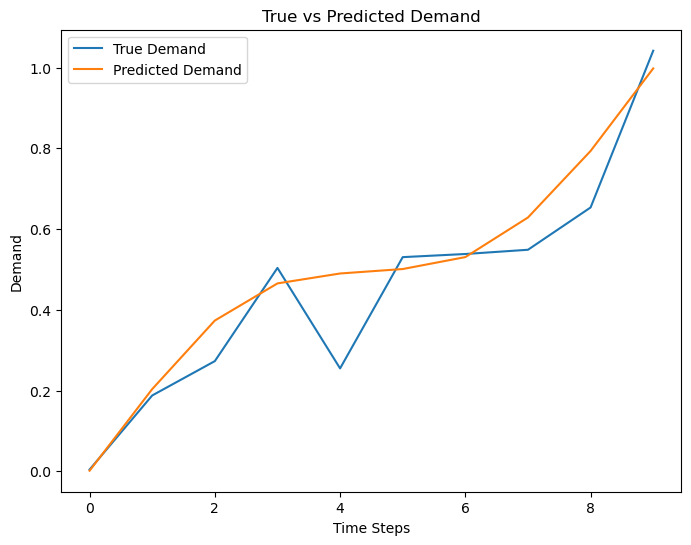

In [11]:
# 改进数据生成：添加趋势和周期性
def generate_synthetic_data(num_samples=1000, seq_len=10, num_features=5):
    """生成具有趋势和周期性的时间序列数据"""
    X = np.zeros((num_samples, seq_len, num_features))
    y = np.zeros((num_samples, seq_len, 1))

    for i in range(num_samples):
        trend = np.linspace(0, 1, seq_len)  # 趋势项
        seasonality = 0.3 * np.sin(np.linspace(0, 2 * np.pi, seq_len))  # 周期项
        noise = 0.1 * np.random.randn(seq_len)  # 噪声项

        for j in range(num_features):
            X[i, :, j] = trend + seasonality + noise  # 特征加入趋势和周期性

        y[i, :, 0] = trend + 0.5 * seasonality + 0.1 * np.random.randn(seq_len)  # 目标值

    return X, y

# 生成新数据
num_samples = 1000
seq_len = 10
num_features = 5
X, y = generate_synthetic_data(num_samples, seq_len, num_features)

# 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 数据集划分
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# 模型结构改进
def build_deep_cnn_lstm_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    # 更深的CNN层
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    
    # 更深的LSTM层
    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))
    
    # 输出层
    model.add(Dense(seq_len, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (seq_len, num_features)
model = build_deep_cnn_lstm_model(input_shape)

# 模型训练
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train.reshape(-1, seq_len),  # 修改y维度用于多步预测
    epochs=200,
    batch_size=32,
    validation_data=(X_val, y_val.reshape(-1, seq_len)),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 评估模型
test_loss, test_mae = model.evaluate(X_test, y_test.reshape(-1, seq_len), verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")

# 预测与反标准化
y_pred = model.predict(X_test)
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
y_pred_rescaled = scaler_y.inverse_transform(y_pred)

# 绘制第一个样本结果
plt.figure(figsize=(8, 6))
plt.plot(range(seq_len), y_test_rescaled[0].flatten(), label='True Demand')
plt.plot(range(seq_len), y_pred_rescaled[0], label='Predicted Demand')
plt.title('True vs Predicted Demand')
plt.xlabel('Time Steps')
plt.ylabel('Demand')
plt.legend()
plt.show()


Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.2375 - mae: 0.4332 - val_loss: 0.0068 - val_mae: 0.0638 - learning_rate: 0.0010
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0354 - mae: 0.1498 - val_loss: 0.0032 - val_mae: 0.0465 - learning_rate: 0.0010
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0215 - mae: 0.1150 - val_loss: 0.0019 - val_mae: 0.0345 - learning_rate: 0.0010
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0207 - mae: 0.1119 - val_loss: 0.0023 - val_mae: 0.0386 - learning_rate: 0.0010
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0178 - mae: 0.1039 - val_loss: 0.0016 - val_mae: 0.0320 - learning_rate: 0.0010
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0148 - mae: 0.0959 - val_loss: 0.0015 - val_mae: 0.0308 - learning_rate: 0.0010
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0127 - mae: 0.0881 - val_loss: 0.0014 - val_mae: 0.0306 - learning_rate: 0.0010
Epoch 

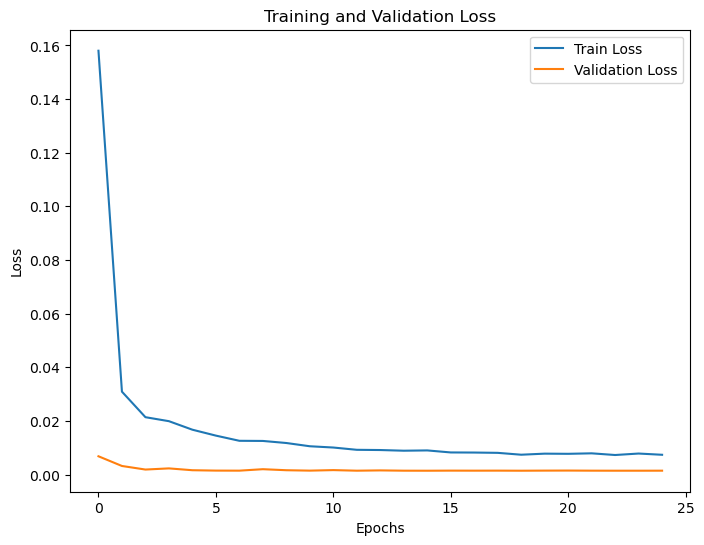

Test Loss: 0.0015, Test MAE: 0.0306
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step


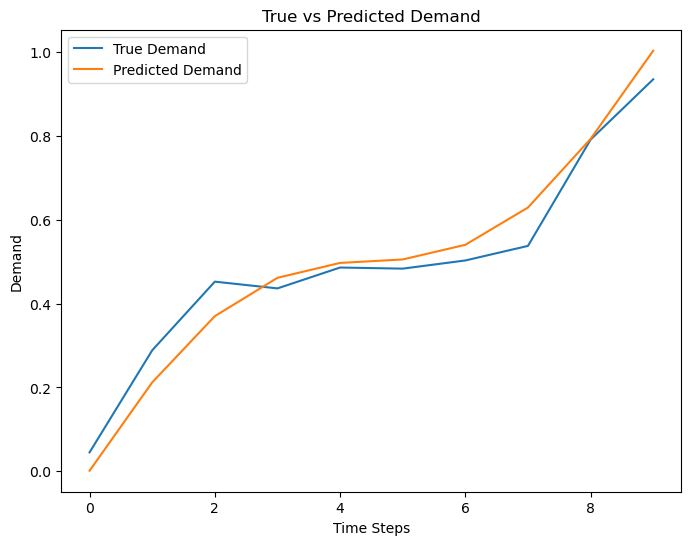

In [12]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 设置随机种子
np.random.seed(42)

# 1. 改进数据生成：添加趋势和周期性
def generate_synthetic_data(num_samples=1000, seq_len=10, num_features=5):
    """生成具有趋势和周期性的时间序列数据"""
    X = np.zeros((num_samples, seq_len, num_features))
    y = np.zeros((num_samples, seq_len, 1))

    for i in range(num_samples):
        trend = np.linspace(0, 1, seq_len)  # 趋势项
        seasonality = 0.3 * np.sin(np.linspace(0, 2 * np.pi, seq_len))  # 周期项
        noise = 0.1 * np.random.randn(seq_len)  # 噪声项

        for j in range(num_features):
            X[i, :, j] = trend + seasonality + noise  # 每个特征加入趋势和周期性

        y[i, :, 0] = trend + 0.5 * seasonality + 0.05 * np.random.randn(seq_len)  # 目标值加入噪声

    return X, y

num_samples = 1000
seq_len = 10
num_features = 5
X, y = generate_synthetic_data(num_samples, seq_len, num_features)

# 2. 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 3. 数据集划分：70%训练集，20%验证集，10%测试集
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# 4. 模型构建
def build_deep_cnn_lstm_model(input_shape):
    """改进版CNN-LSTM模型"""
    model = Sequential()
    model.add(Input(shape=input_shape))

    # CNN层：增加深度
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    # LSTM层：增加深度和单元数
    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))

    # 输出层
    model.add(Dense(seq_len, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (seq_len, num_features)
model = build_deep_cnn_lstm_model(input_shape)

# 5. 模型训练
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train.reshape(-1, seq_len),  # 修改y维度用于多步预测
    epochs=200,
    batch_size=32,
    validation_data=(X_val, y_val.reshape(-1, seq_len)),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 6. 绘制训练过程的损失曲线
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 7. 模型评估
test_loss, test_mae = model.evaluate(X_test, y_test.reshape(-1, seq_len), verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")

# 8. 预测结果与实际值对比
y_pred = model.predict(X_test)

# 反标准化
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
y_pred_rescaled = scaler_y.inverse_transform(y_pred).reshape(y_test.shape)

# 绘制第一个样本的预测结果与实际值
plt.figure(figsize=(8, 6))
time_steps = range(seq_len)
plt.plot(time_steps, y_test_rescaled[0].flatten(), label='True Demand')
plt.plot(time_steps, y_pred_rescaled[0].flatten(), label='Predicted Demand')
plt.title('True vs Predicted Demand')
plt.xlabel('Time Steps')
plt.ylabel('Demand')
plt.legend()
plt.show()


In [17]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv  # 正确的导入方式
from stable_baselines3.common.vec_env import DummyVecEnv

# 使用 shimmy 自动兼容
from stable_baselines3.common.vec_env import DummyVecEnv

# 使用 DummyVecEnv 包装自定义环境
env = DummyVecEnv([lambda: CustomTransportEnv()])



import gymnasium as gym


# 设置随机种子
np.random.seed(42)

# 1. 改进数据生成：添加趋势和周期性
def generate_synthetic_data(num_samples=1000, seq_len=10, num_features=5):
    """生成具有趋势和周期性的时间序列数据"""
    X = np.zeros((num_samples, seq_len, num_features))
    y = np.zeros((num_samples, seq_len, 1))

    for i in range(num_samples):
        trend = np.linspace(0, 1, seq_len)  # 趋势项
        seasonality = 0.3 * np.sin(np.linspace(0, 2 * np.pi, seq_len))  # 周期项
        noise = 0.1 * np.random.randn(seq_len)  # 噪声项

        for j in range(num_features):
            X[i, :, j] = trend + seasonality + noise  # 每个特征加入趋势和周期性

        y[i, :, 0] = trend + 0.5 * seasonality + 0.05 * np.random.randn(seq_len)  # 目标值加入噪声

    return X, y

num_samples = 1000
seq_len = 10
num_features = 5
X, y = generate_synthetic_data(num_samples, seq_len, num_features)

# 2. 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 3. 数据集划分：70%训练集，20%验证集，10%测试集
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# 4. CNN-LSTM模型构建
def build_deep_cnn_lstm_model(input_shape):
    """改进版CNN-LSTM模型"""
    model = Sequential()
    model.add(Input(shape=input_shape))

    # CNN层：增加深度
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    # LSTM层：增加深度和单元数
    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))

    # 输出层
    model.add(Dense(seq_len, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (seq_len, num_features)
model = build_deep_cnn_lstm_model(input_shape)

# 5. CNN-LSTM模型训练
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train.reshape(-1, seq_len),  # 修改y维度用于多步预测
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val.reshape(-1, seq_len)),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 绘制训练过程的损失曲线
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 9. 改进的自定义Gym环境
class CustomTransportEnv(gym.Env):
    def __init__(self):
        super(CustomTransportEnv, self).__init__()
        self.state_shape = seq_len
        self.action_shape = 5  # 动作数量
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.state_shape,), dtype=np.float32)
        self.action_space = gym.spaces.Discrete(self.action_shape)
        self.reset()

    def reset(self):
        """环境重置"""
        self.current_step = 0
        self.demand = y_test.reshape(-1, seq_len)  # 使用测试集需求作为环境输入
        self.state = self.demand[self.current_step]  # 初始化状态
        self.total_cost = 0  # 累计成本
        return self.state

    def step(self, action):
        """
        环境在当前动作下的动态变化
        :param action: 动作（分配策略）
        :return: (新的状态, 奖励, 是否结束, 附加信息)
        """
        # 定义资源分配逻辑
        resource_allocation = action * 0.2
        demand = np.mean(self.state)
        reward = -np.abs(resource_allocation - demand)  # 越接近需求奖励越高
        self.total_cost += resource_allocation * 10

        # 更新状态
        self.current_step += 1
        done = self.current_step >= len(self.demand) - 1
        if not done:
            self.state = self.demand[self.current_step]
        else:
            self.state = np.zeros_like(self.state)
        return self.state, reward, done, {'total_cost': self.total_cost}

# 使用Stable-Baselines3训练DQN
env = DummyVecEnv([lambda: CustomTransportEnv()])
model = DQN('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=5000)

# 测试DQN模型
obs = env.reset()
for _ in range(10):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)
    print(f"Action: {action}, Reward: {reward}, Total Cost: {info}")


Using cpu device


ValueError: not enough values to unpack (expected 5, got 4)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.2398 - mae: 0.4355 - val_loss: 0.0067 - val_mae: 0.0670 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0300 - mae: 0.1389 - val_loss: 0.0024 - val_mae: 0.0393 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0211 - mae: 0.1152 - val_loss: 0.0017 - val_mae: 0.0327 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0171 - mae: 0.1041 - val_loss: 0.0015 - val_mae: 0.0314 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0152 - mae: 0.0986 - val_loss: 0.0016 - val_mae: 0.0319 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0143 - mae: 0.0938 - val_loss: 0.0015 - val_mae: 0.0312 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0118 - mae: 0.0861 - val_loss: 0.0015 - val_mae: 0.0314 - learning_rate: 0.0010
Epoch 8/50
22

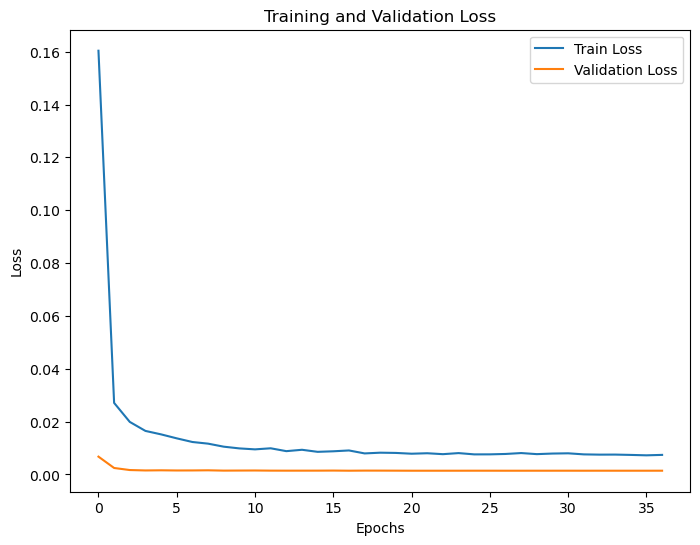

Using cpu device


ValueError: not enough values to unpack (expected 5, got 4)

In [18]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv  # 正确的导入方式

import gymnasium as gym

# 设置随机种子
np.random.seed(42)

# 1. 改进数据生成：添加趋势和周期性
def generate_synthetic_data(num_samples=1000, seq_len=10, num_features=5):
    """生成具有趋势和周期性的时间序列数据"""
    X = np.zeros((num_samples, seq_len, num_features))
    y = np.zeros((num_samples, seq_len, 1))

    for i in range(num_samples):
        trend = np.linspace(0, 1, seq_len)  # 趋势项
        seasonality = 0.3 * np.sin(np.linspace(0, 2 * np.pi, seq_len))  # 周期项
        noise = 0.1 * np.random.randn(seq_len)  # 噪声项

        for j in range(num_features):
            X[i, :, j] = trend + seasonality + noise  # 每个特征加入趋势和周期性

        y[i, :, 0] = trend + 0.5 * seasonality + 0.05 * np.random.randn(seq_len)  # 目标值加入噪声

    return X, y

num_samples = 1000
seq_len = 10
num_features = 5
X, y = generate_synthetic_data(num_samples, seq_len, num_features)

# 2. 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 3. 数据集划分：70%训练集，20%验证集，10%测试集
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# 4. CNN-LSTM模型构建
def build_deep_cnn_lstm_model(input_shape):
    """改进版CNN-LSTM模型"""
    model = Sequential()
    model.add(Input(shape=input_shape))

    # CNN层：增加深度
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    # LSTM层：增加深度和单元数
    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))

    # 输出层
    model.add(Dense(seq_len, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (seq_len, num_features)
model = build_deep_cnn_lstm_model(input_shape)

# 5. CNN-LSTM模型训练
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train.reshape(-1, seq_len),  # 修改y维度用于多步预测
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val.reshape(-1, seq_len)),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 绘制训练过程的损失曲线
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 9. 改进的自定义Gym环境
class CustomTransportEnv(gym.Env):
    def __init__(self):
        super(CustomTransportEnv, self).__init__()
        self.state_shape = seq_len
        self.action_shape = 5  # 动作数量
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.state_shape,), dtype=np.float32)
        self.action_space = gym.spaces.Discrete(self.action_shape)
        self.reset()

    def reset(self, seed=None, options=None):
        """环境重置，兼容Gymnasium的seed和options参数"""
        super().reset(seed=seed)
        self.current_step = 0
        self.demand = y_test.reshape(-1, seq_len)  # 使用测试集需求作为环境输入
        self.state = self.demand[self.current_step]  # 初始化状态
        self.total_cost = 0  # 累计成本
        return self.state, {}

    def step(self, action):
        """
        环境在当前动作下的动态变化
        :param action: 动作（分配策略）
        :return: (新的状态, 奖励, 是否结束, 附加信息)
        """
        # 定义资源分配逻辑
        resource_allocation = action * 0.2
        demand = np.mean(self.state)
        reward = -np.abs(resource_allocation - demand)  # 越接近需求奖励越高
        self.total_cost += resource_allocation * 10

        # 更新状态
        self.current_step += 1
        done = self.current_step >= len(self.demand) - 1
        if not done:
            self.state = self.demand[self.current_step]
        else:
            self.state = np.zeros_like(self.state)
        return self.state, reward, done, {'total_cost': self.total_cost}

# 使用Stable-Baselines3训练DQN
env = DummyVecEnv([lambda: CustomTransportEnv()])
model = DQN('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=5000)

# 测试DQN模型
obs = env.reset()
for _ in range(10):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)
    print(f"Action: {action}, Reward: {reward}, Total Cost: {info}")


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.2209 - mae: 0.4134 - val_loss: 0.0040 - val_mae: 0.0492 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0292 - mae: 0.1361 - val_loss: 0.0025 - val_mae: 0.0394 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0194 - mae: 0.1094 - val_loss: 0.0017 - val_mae: 0.0330 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0164 - mae: 0.1009 - val_loss: 0.0017 - val_mae: 0.0333 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0157 - mae: 0.0983 - val_loss: 0.0015 - val_mae: 0.0312 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0143 - mae: 0.0936 - val_loss: 0.0015 - val_mae: 0.0311 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0127 - mae: 0.0887 - val_loss: 0.0015 - val_mae: 0.0309 - learning_rate: 0.0010
Epoch 8/50
22

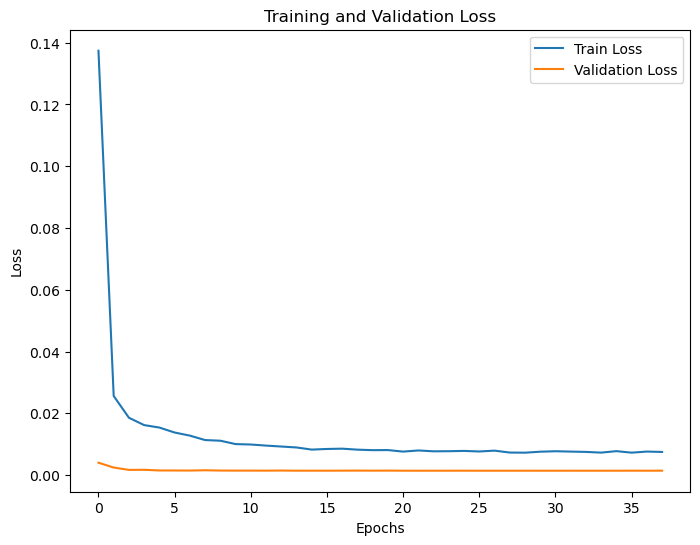

Using cpu device
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.248    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1243     |
|    time_elapsed     | 0        |
|    total_timesteps  | 396      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00271  |
|    n_updates        | 73       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1046     |
|    time_elapsed     | 0        |
|    total_timesteps  | 792      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000654 |
|    n_updates        | 172      |
----------------------------------
----------------------------------
| rollout/            |          |
|  

ValueError: not enough values to unpack (expected 5, got 4)

In [19]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv  # 正确的导入方式

import gymnasium as gym

# 设置随机种子
np.random.seed(42)

# 1. 改进数据生成：添加趋势和周期性
def generate_synthetic_data(num_samples=1000, seq_len=10, num_features=5):
    """生成具有趋势和周期性的时间序列数据"""
    X = np.zeros((num_samples, seq_len, num_features))
    y = np.zeros((num_samples, seq_len, 1))

    for i in range(num_samples):
        trend = np.linspace(0, 1, seq_len)  # 趋势项
        seasonality = 0.3 * np.sin(np.linspace(0, 2 * np.pi, seq_len))  # 周期项
        noise = 0.1 * np.random.randn(seq_len)  # 噪声项

        for j in range(num_features):
            X[i, :, j] = trend + seasonality + noise  # 每个特征加入趋势和周期性

        y[i, :, 0] = trend + 0.5 * seasonality + 0.05 * np.random.randn(seq_len)  # 目标值加入噪声

    return X, y

num_samples = 1000
seq_len = 10
num_features = 5
X, y = generate_synthetic_data(num_samples, seq_len, num_features)

# 2. 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 3. 数据集划分：70%训练集，20%验证集，10%测试集
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# 4. CNN-LSTM模型构建
def build_deep_cnn_lstm_model(input_shape):
    """改进版CNN-LSTM模型"""
    model = Sequential()
    model.add(Input(shape=input_shape))

    # CNN层：增加深度
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    # LSTM层：增加深度和单元数
    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))

    # 输出层
    model.add(Dense(seq_len, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (seq_len, num_features)
model = build_deep_cnn_lstm_model(input_shape)

# 5. CNN-LSTM模型训练
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train.reshape(-1, seq_len),  # 修改y维度用于多步预测
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val.reshape(-1, seq_len)),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 绘制训练过程的损失曲线
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 9. 改进的自定义Gym环境
class CustomTransportEnv(gym.Env):
    def __init__(self):
        super(CustomTransportEnv, self).__init__()
        self.state_shape = seq_len
        self.action_shape = 5  # 动作数量
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.state_shape,), dtype=np.float32)
        self.action_space = gym.spaces.Discrete(self.action_shape)
        self.reset()

    def reset(self, seed=None, options=None):
        """环境重置，兼容Gymnasium的seed和options参数"""
        super().reset(seed=seed)
        self.current_step = 0
        self.demand = y_test.reshape(-1, seq_len)  # 使用测试集需求作为环境输入
        self.state = self.demand[self.current_step]  # 初始化状态
        self.total_cost = 0  # 累计成本
        return self.state, {}

    def step(self, action):
        """
        环境在当前动作下的动态变化
        :param action: 动作（分配策略）
        :return: (新的状态, 奖励, 是否结束, 附加信息)
        """
        resource_allocation = action * 0.2
        demand = np.mean(self.state)
        reward = -np.abs(resource_allocation - demand)  # 越接近需求奖励越高
        self.total_cost += resource_allocation * 10

        # 更新状态
        self.current_step += 1
        done = self.current_step >= len(self.demand) - 1
        if not done:
            self.state = self.demand[self.current_step]
        else:
            self.state = np.zeros_like(self.state)
        return self.state, reward, done, False, {'total_cost': self.total_cost}

# 使用Stable-Baselines3训练DQN
env = DummyVecEnv([lambda: CustomTransportEnv()])
model = DQN('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=5000)

# 测试DQN模型
obs = env.reset()
for _ in range(10):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
    print(f"Action: {action}, Reward: {reward}, Total Cost: {info}")


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.2414 - mae: 0.4384 - val_loss: 0.0116 - val_mae: 0.0946 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0353 - mae: 0.1508 - val_loss: 0.0031 - val_mae: 0.0440 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0225 - mae: 0.1185 - val_loss: 0.0021 - val_mae: 0.0372 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0192 - mae: 0.1095 - val_loss: 0.0019 - val_mae: 0.0353 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0165 - mae: 0.1014 - val_loss: 0.0015 - val_mae: 0.0314 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0143 - mae: 0.0946 - val_loss: 0.0015 - val_mae: 0.0308 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0133 - mae: 0.0907 - val_loss: 0.0017 - val_mae: 0.0329 - learning_rate: 0.0010
Epoch 8/50
22

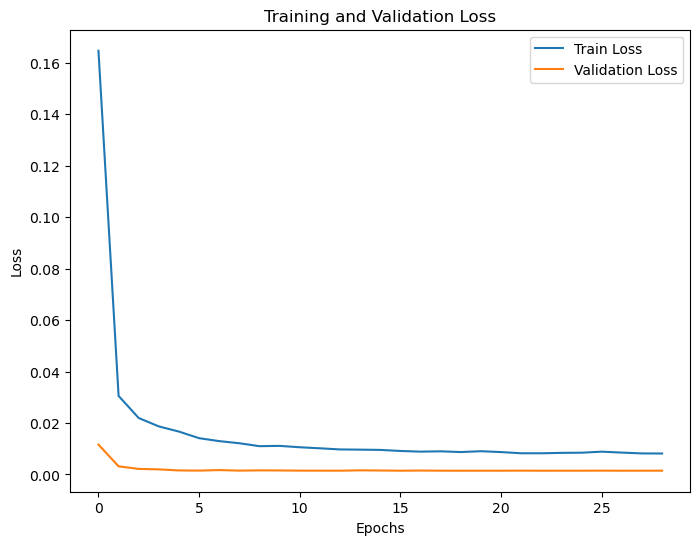

Using cpu device
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.248    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1166     |
|    time_elapsed     | 0        |
|    total_timesteps  | 396      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00929  |
|    n_updates        | 73       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 986      |
|    time_elapsed     | 0        |
|    total_timesteps  | 792      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000223 |
|    n_updates        | 172      |
----------------------------------
----------------------------------
| rollout/            |          |
|  

In [20]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv  # 正确的导入方式

import gymnasium as gym

# 设置随机种子
np.random.seed(42)

# 1. 改进数据生成：添加趋势和周期性
def generate_synthetic_data(num_samples=1000, seq_len=10, num_features=5):
    """生成具有趋势和周期性的时间序列数据"""
    X = np.zeros((num_samples, seq_len, num_features))
    y = np.zeros((num_samples, seq_len, 1))

    for i in range(num_samples):
        trend = np.linspace(0, 1, seq_len)  # 趋势项
        seasonality = 0.3 * np.sin(np.linspace(0, 2 * np.pi, seq_len))  # 周期项
        noise = 0.1 * np.random.randn(seq_len)  # 噪声项

        for j in range(num_features):
            X[i, :, j] = trend + seasonality + noise  # 每个特征加入趋势和周期性

        y[i, :, 0] = trend + 0.5 * seasonality + 0.05 * np.random.randn(seq_len)  # 目标值加入噪声

    return X, y

num_samples = 1000
seq_len = 10
num_features = 5
X, y = generate_synthetic_data(num_samples, seq_len, num_features)

# 2. 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 3. 数据集划分：70%训练集，20%验证集，10%测试集
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# 4. CNN-LSTM模型构建
def build_deep_cnn_lstm_model(input_shape):
    """改进版CNN-LSTM模型"""
    model = Sequential()
    model.add(Input(shape=input_shape))

    # CNN层：增加深度
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    # LSTM层：增加深度和单元数
    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))

    # 输出层
    model.add(Dense(seq_len, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (seq_len, num_features)
model = build_deep_cnn_lstm_model(input_shape)

# 5. CNN-LSTM模型训练
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train.reshape(-1, seq_len),  # 修改y维度用于多步预测
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val.reshape(-1, seq_len)),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 绘制训练过程的损失曲线
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 9. 改进的自定义Gym环境
class CustomTransportEnv(gym.Env):
    def __init__(self):
        super(CustomTransportEnv, self).__init__()
        self.state_shape = seq_len
        self.action_shape = 5  # 动作数量
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.state_shape,), dtype=np.float32)
        self.action_space = gym.spaces.Discrete(self.action_shape)
        self.reset()

    def reset(self, seed=None, options=None):
        """环境重置，兼容Gymnasium的seed和options参数"""
        super().reset(seed=seed)
        self.current_step = 0
        self.demand = y_test.reshape(-1, seq_len)  # 使用测试集需求作为环境输入
        self.state = self.demand[self.current_step]  # 初始化状态
        self.total_cost = 0  # 累计成本
        return self.state, {}

    def step(self, action):
        """
        环境在当前动作下的动态变化
        :param action: 动作（分配策略）
        :return: (新的状态, 奖励, 是否结束, 附加信息)
        """
        # 定义资源分配逻辑
        resource_allocation = action * 0.2
        demand = np.mean(self.state)
        reward = -np.abs(resource_allocation - demand)  # 越接近需求奖励越高
        self.total_cost += resource_allocation * 10

        # 更新状态
        self.current_step += 1
        done = self.current_step >= len(self.demand) - 1
        if not done:
            self.state = self.demand[self.current_step]
        else:
            self.state = np.zeros_like(self.state)
        return self.state, reward, done, False, {'total_cost': self.total_cost}

# 使用Stable-Baselines3训练DQN
env = DummyVecEnv([lambda: CustomTransportEnv()])
model = DQN('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=5000)

# 测试DQN模型
obs = env.reset()
for _ in range(10):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)
    print(f"Action: {action}, Reward: {reward}, Total Cost: {info}")


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.2370 - mae: 0.4349 - val_loss: 0.0100 - val_mae: 0.0743 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0299 - mae: 0.1370 - val_loss: 0.0023 - val_mae: 0.0383 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0200 - mae: 0.1120 - val_loss: 0.0019 - val_mae: 0.0346 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0162 - mae: 0.1014 - val_loss: 0.0017 - val_mae: 0.0332 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0150 - mae: 0.0978 - val_loss: 0.0015 - val_mae: 0.0314 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0127 - mae: 0.0892 - val_loss: 0.0020 - val_mae: 0.0362 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0120 - mae: 0.0872 - val_loss: 0.0018 - val_mae: 0.0336 - learning_rate: 0.0010
Epoch 8/50
22

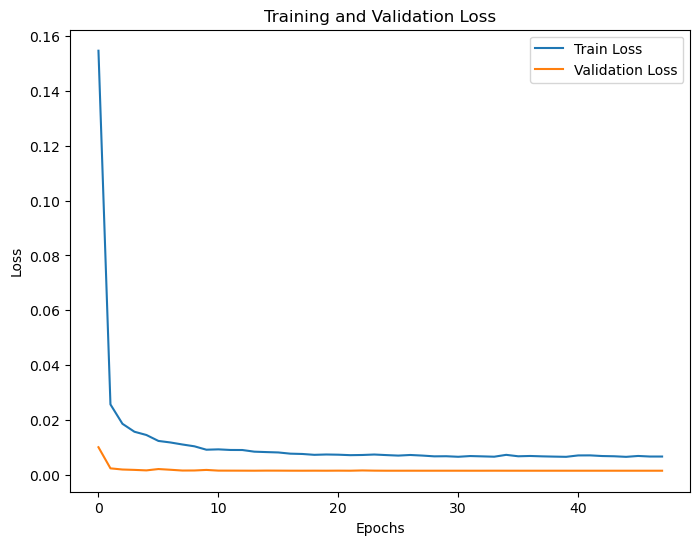

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step


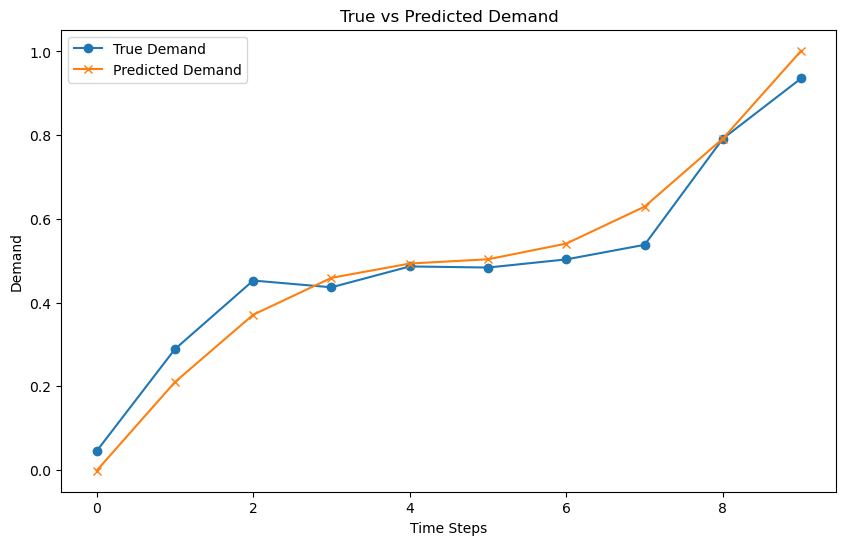

Using cpu device
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.248    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1527     |
|    time_elapsed     | 0        |
|    total_timesteps  | 396      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0135   |
|    n_updates        | 73       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1090     |
|    time_elapsed     | 0        |
|    total_timesteps  | 792      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00162  |
|    n_updates        | 172      |
----------------------------------
----------------------------------
| rollout/            |          |
|  

TypeError: list indices must be integers or slices, not str

In [21]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv  # 正确的导入方式

import gymnasium as gym

# 设置随机种子
np.random.seed(42)

# 1. 改进数据生成：添加趋势和周期性
def generate_synthetic_data(num_samples=1000, seq_len=10, num_features=5):
    """生成具有趋势和周期性的时间序列数据"""
    X = np.zeros((num_samples, seq_len, num_features))
    y = np.zeros((num_samples, seq_len, 1))

    for i in range(num_samples):
        trend = np.linspace(0, 1, seq_len)  # 趋势项
        seasonality = 0.3 * np.sin(np.linspace(0, 2 * np.pi, seq_len))  # 周期项
        noise = 0.1 * np.random.randn(seq_len)  # 噪声项

        for j in range(num_features):
            X[i, :, j] = trend + seasonality + noise  # 每个特征加入趋势和周期性

        y[i, :, 0] = trend + 0.5 * seasonality + 0.05 * np.random.randn(seq_len)  # 目标值加入噪声

    return X, y

num_samples = 1000
seq_len = 10
num_features = 5
X, y = generate_synthetic_data(num_samples, seq_len, num_features)

# 2. 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 3. 数据集划分：70%训练集，20%验证集，10%测试集
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# 4. CNN-LSTM模型构建
def build_deep_cnn_lstm_model(input_shape):
    """改进版CNN-LSTM模型"""
    model = Sequential()
    model.add(Input(shape=input_shape))

    # CNN层：增加深度
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    # LSTM层：增加深度和单元数
    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))

    # 输出层
    model.add(Dense(seq_len, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (seq_len, num_features)
model = build_deep_cnn_lstm_model(input_shape)

# 5. CNN-LSTM模型训练
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train.reshape(-1, seq_len),  # 修改y维度用于多步预测
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val.reshape(-1, seq_len)),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 绘制训练过程的损失曲线
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 绘制CNN-LSTM预测结果与真实值对比
y_pred = model.predict(X_test)
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
y_pred_rescaled = scaler_y.inverse_transform(y_pred).reshape(y_test.shape)

plt.figure(figsize=(10, 6))
plt.plot(range(seq_len), y_test_rescaled[0].flatten(), label='True Demand', marker='o')
plt.plot(range(seq_len), y_pred_rescaled[0].flatten(), label='Predicted Demand', marker='x')
plt.title('True vs Predicted Demand')
plt.xlabel('Time Steps')
plt.ylabel('Demand')
plt.legend()
plt.show()

# 9. 改进的自定义Gym环境
class CustomTransportEnv(gym.Env):
    def __init__(self):
        super(CustomTransportEnv, self).__init__()
        self.state_shape = seq_len
        self.action_shape = 5  # 动作数量
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.state_shape,), dtype=np.float32)
        self.action_space = gym.spaces.Discrete(self.action_shape)
        self.reset()

    def reset(self, seed=None, options=None):
        """环境重置，兼容Gymnasium的seed和options参数"""
        super().reset(seed=seed)
        self.current_step = 0
        self.demand = y_test.reshape(-1, seq_len)  # 使用测试集需求作为环境输入
        self.state = self.demand[self.current_step]  # 初始化状态
        self.total_cost = 0  # 累计成本
        return self.state, {}

    def step(self, action):
        """
        环境在当前动作下的动态变化
        :param action: 动作（分配策略）
        :return: (新的状态, 奖励, 是否结束, 附加信息)
        """
        # 定义资源分配逻辑
        resource_allocation = action * 0.2
        demand = np.mean(self.state)
        reward = -np.abs(resource_allocation - demand)  # 越接近需求奖励越高
        self.total_cost += resource_allocation * 10

        # 更新状态
        self.current_step += 1
        done = self.current_step >= len(self.demand) - 1
        if not done:
            self.state = self.demand[self.current_step]
        else:
            self.state = np.zeros_like(self.state)
        return self.state, reward, done, False, {'total_cost': self.total_cost}

# 使用Stable-Baselines3训练DQN
env = DummyVecEnv([lambda: CustomTransportEnv()])
model = DQN('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=5000)

# 测试DQN模型
obs = env.reset()
rewards = []
total_costs = []
for _ in range(10):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)
    rewards.append(reward)
    total_costs.append(info['total_cost'])
    print(f"Action: {action}, Reward: {reward}, Total Cost: {info}")

# 绘制DQN累计奖励和成本曲线
plt.figure(figsize=(10, 6))
plt.plot(rewards, label='Rewards', marker='o')
plt.title('Rewards per Step')
plt.xlabel('Steps')
plt.ylabel('Reward')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(total_costs, label='Total Cost', marker='x')
plt.title('Total Cost per Step')
plt.xlabel('Steps')
plt.ylabel('Cost')
plt.legend()
plt.show()


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.2435 - mae: 0.4429 - val_loss: 0.0099 - val_mae: 0.0770 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0401 - mae: 0.1580 - val_loss: 0.0024 - val_mae: 0.0396 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0269 - mae: 0.1294 - val_loss: 0.0020 - val_mae: 0.0356 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0206 - mae: 0.1126 - val_loss: 0.0018 - val_mae: 0.0343 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0185 - mae: 0.1067 - val_loss: 0.0021 - val_mae: 0.0367 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0167 - mae: 0.1016 - val_loss: 0.0015 - val_mae: 0.0311 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0144 - mae: 0.0944 - val_loss: 0.0016 - val_mae: 0.0317 - learning_rate: 0.0010
Epoch 8/50
22

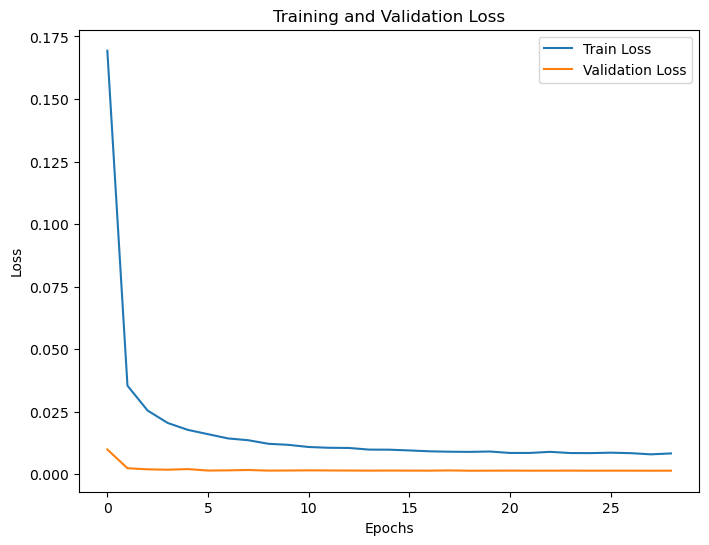

1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 387ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002105C527D80> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step


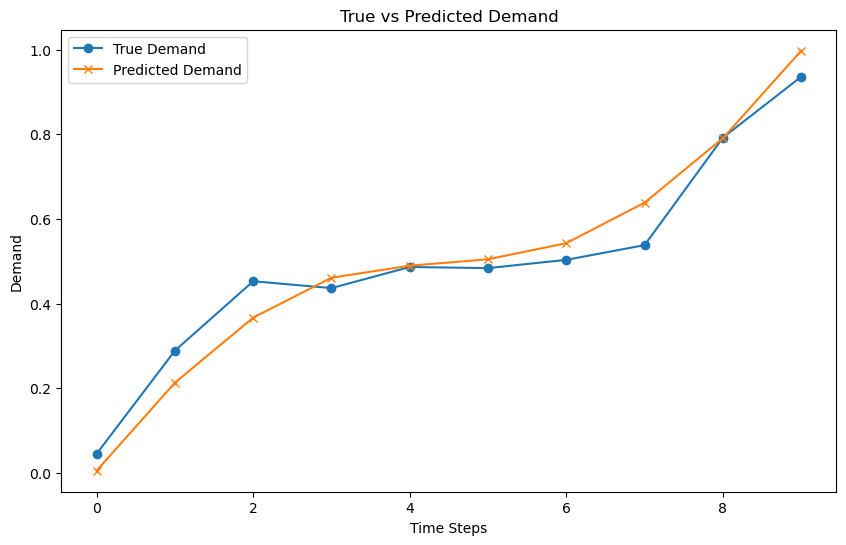

Using cpu device


ValueError: not enough values to unpack (expected 5, got 4)

In [23]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv  # 正确的导入方式

import gymnasium as gym

# 设置随机种子
np.random.seed(42)

# 1. 改进数据生成：添加趋势和周期性
def generate_synthetic_data(num_samples=1000, seq_len=10, num_features=5):
    """生成具有趋势和周期性的时间序列数据"""
    X = np.zeros((num_samples, seq_len, num_features))
    y = np.zeros((num_samples, seq_len, 1))

    for i in range(num_samples):
        trend = np.linspace(0, 1, seq_len)  # 趋势项
        seasonality = 0.3 * np.sin(np.linspace(0, 2 * np.pi, seq_len))  # 周期项
        noise = 0.1 * np.random.randn(seq_len)  # 噪声项

        for j in range(num_features):
            X[i, :, j] = trend + seasonality + noise  # 每个特征加入趋势和周期性

        y[i, :, 0] = trend + 0.5 * seasonality + 0.05 * np.random.randn(seq_len)  # 目标值加入噪声

    return X, y

num_samples = 1000
seq_len = 10
num_features = 5
X, y = generate_synthetic_data(num_samples, seq_len, num_features)

# 2. 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 3. 数据集划分：70%训练集，20%验证集，10%测试集
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# 4. CNN-LSTM模型构建
def build_deep_cnn_lstm_model(input_shape):
    """改进版CNN-LSTM模型"""
    model = Sequential()
    model.add(Input(shape=input_shape))

    # CNN层：增加深度
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    # LSTM层：增加深度和单元数
    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))

    # 输出层
    model.add(Dense(seq_len, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (seq_len, num_features)
model = build_deep_cnn_lstm_model(input_shape)

# 5. CNN-LSTM模型训练
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train.reshape(-1, seq_len),  # 修改y维度用于多步预测
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val.reshape(-1, seq_len)),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 绘制训练过程的损失曲线
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 绘制CNN-LSTM预测结果与真实值对比
y_pred = model.predict(X_test)
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
y_pred_rescaled = scaler_y.inverse_transform(y_pred).reshape(y_test.shape)

plt.figure(figsize=(10, 6))
plt.plot(range(seq_len), y_test_rescaled[0].flatten(), label='True Demand', marker='o')
plt.plot(range(seq_len), y_pred_rescaled[0].flatten(), label='Predicted Demand', marker='x')
plt.title('True vs Predicted Demand')
plt.xlabel('Time Steps')
plt.ylabel('Demand')
plt.legend()
plt.show()

# 9. 改进的自定义Gym环境
class CustomTransportEnv(gym.Env):
    def __init__(self):
        super(CustomTransportEnv, self).__init__()
        self.state_shape = seq_len
        self.action_shape = 5  # 动作数量
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.state_shape,), dtype=np.float32)
        self.action_space = gym.spaces.Discrete(self.action_shape)
        self.reset()

    def reset(self, seed=None, options=None):
        """环境重置，兼容Gymnasium的seed和options参数"""
        super().reset(seed=seed)
        self.current_step = 0
        self.demand = y_test.reshape(-1, seq_len)  # 使用测试集需求作为环境输入
        self.state = self.demand[self.current_step]  # 初始化状态
        self.total_cost = 0  # 累计成本
        return self.state, {}

    def step(self, action):
        """
        环境在当前动作下的动态变化
        :param action: 动作（分配策略）
        :return: (新的状态, 奖励, 是否结束, 附加信息)
        """
        # 定义资源分配逻辑
        resource_allocation = action * 0.2
        demand = np.mean(self.state)
        reward = -np.abs(resource_allocation - demand)  # 越接近需求奖励越高
        self.total_cost += resource_allocation * 10

        # 更新状态
        self.current_step += 1
        done = self.current_step >= len(self.demand) - 1
        if not done:
            self.state = self.demand[self.current_step]
        else:
            self.state = np.zeros_like(self.state)
        return self.state, reward, done, {'total_cost': self.total_cost}

# 使用Stable-Baselines3训练DQN
env = DummyVecEnv([lambda: CustomTransportEnv()])
model = DQN('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=5000)

# 测试DQN模型
obs = env.reset()
rewards = []
total_costs = []
for _ in range(10):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)
    rewards.append(reward)
    total_costs.append(info[0]['total_cost'])
    print(f"Action: {action}, Reward: {reward}, Total Cost: {info}")

# 绘制DQN累计奖励和成本曲线
plt.figure(figsize=(10, 6))
plt.plot(rewards, label='Rewards', marker='o')
plt.title('Rewards per Step')
plt.xlabel('Steps')
plt.ylabel('Reward')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot([info['total_cost'] for info in total_costs], label='Total Cost', marker='x')
plt.title('Total Cost per Step')
plt.xlabel('Steps')
plt.ylabel('Cost')
plt.legend()
plt.show()



Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.2514 - mae: 0.4544 - val_loss: 0.0067 - val_mae: 0.0679 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0348 - mae: 0.1470 - val_loss: 0.0025 - val_mae: 0.0398 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0227 - mae: 0.1199 - val_loss: 0.0017 - val_mae: 0.0327 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0183 - mae: 0.1062 - val_loss: 0.0016 - val_mae: 0.0321 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0164 - mae: 0.1010 - val_loss: 0.0016 - val_mae: 0.0320 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0148 - mae: 0.0965 - val_loss: 0.0015 - val_mae: 0.0314 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0145 - mae: 0.0941 - val_loss: 0.0015 - val_mae: 0.0310 - learning_rate: 0.0010
Epoch 8/50
22

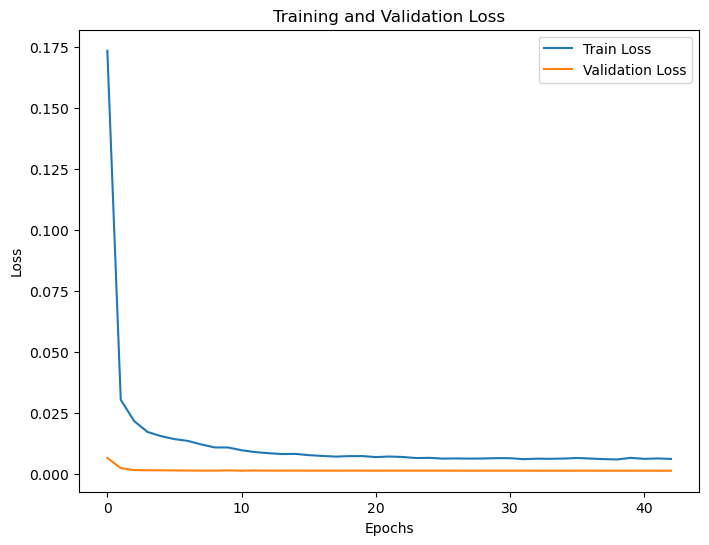

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step


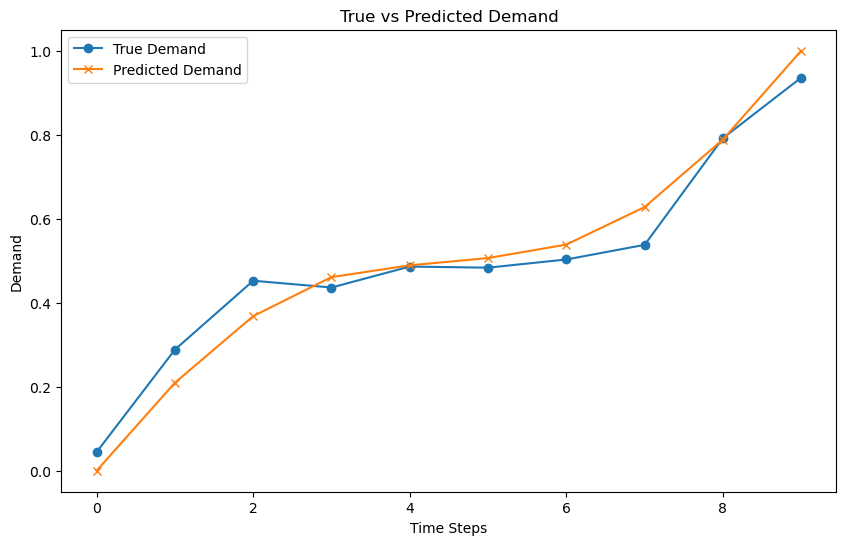

Using cpu device


ValueError: not enough values to unpack (expected 5, got 4)

In [24]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv  # 正确的导入方式

import gymnasium as gym

# 设置随机种子
np.random.seed(42)

# 1. 改进数据生成：添加趋势和周期性
def generate_synthetic_data(num_samples=1000, seq_len=10, num_features=5):
    """生成具有趋势和周期性的时间序列数据"""
    X = np.zeros((num_samples, seq_len, num_features))
    y = np.zeros((num_samples, seq_len, 1))

    for i in range(num_samples):
        trend = np.linspace(0, 1, seq_len)  # 趋势项
        seasonality = 0.3 * np.sin(np.linspace(0, 2 * np.pi, seq_len))  # 周期项
        noise = 0.1 * np.random.randn(seq_len)  # 噪声项

        for j in range(num_features):
            X[i, :, j] = trend + seasonality + noise  # 每个特征加入趋势和周期性

        y[i, :, 0] = trend + 0.5 * seasonality + 0.05 * np.random.randn(seq_len)  # 目标值加入噪声

    return X, y

num_samples = 1000
seq_len = 10
num_features = 5
X, y = generate_synthetic_data(num_samples, seq_len, num_features)

# 2. 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 3. 数据集划分：70%训练集，20%验证集，10%测试集
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# 4. CNN-LSTM模型构建
def build_deep_cnn_lstm_model(input_shape):
    """改进版CNN-LSTM模型"""
    model = Sequential()
    model.add(Input(shape=input_shape))

    # CNN层：增加深度
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    # LSTM层：增加深度和单元数
    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))

    # 输出层
    model.add(Dense(seq_len, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (seq_len, num_features)
model = build_deep_cnn_lstm_model(input_shape)

# 5. CNN-LSTM模型训练
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train.reshape(-1, seq_len),  # 修改y维度用于多步预测
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val.reshape(-1, seq_len)),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 绘制训练过程的损失曲线
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 绘制CNN-LSTM预测结果与真实值对比
y_pred = model.predict(X_test)
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
y_pred_rescaled = scaler_y.inverse_transform(y_pred).reshape(y_test.shape)

plt.figure(figsize=(10, 6))
plt.plot(range(seq_len), y_test_rescaled[0].flatten(), label='True Demand', marker='o')
plt.plot(range(seq_len), y_pred_rescaled[0].flatten(), label='Predicted Demand', marker='x')
plt.title('True vs Predicted Demand')
plt.xlabel('Time Steps')
plt.ylabel('Demand')
plt.legend()
plt.show()

# 9. 改进的自定义Gym环境
class CustomTransportEnv(gym.Env):
    def __init__(self):
        super(CustomTransportEnv, self).__init__()
        self.state_shape = seq_len
        self.action_shape = 5  # 动作数量
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.state_shape,), dtype=np.float32)
        self.action_space = gym.spaces.Discrete(self.action_shape)
        self.reset()

    def reset(self, seed=None, options=None):
        """环境重置，兼容Gymnasium的seed和options参数"""
        super().reset(seed=seed)
        self.current_step = 0
        self.demand = y_test.reshape(-1, seq_len)  # 使用测试集需求作为环境输入
        self.state = self.demand[self.current_step]  # 初始化状态
        self.total_cost = 0  # 累计成本
        return self.state, {}

    def step(self, action):
        """
        环境在当前动作下的动态变化
        :param action: 动作（分配策略）
        :return: (新的状态, 奖励, 是否结束, 附加信息)
        """
        # 定义资源分配逻辑
        resource_allocation = action * 0.2
        demand = np.mean(self.state)
        reward = -np.abs(resource_allocation - demand)  # 越接近需求奖励越高
        self.total_cost += resource_allocation * 10

        # 更新状态
        self.current_step += 1
        done = self.current_step >= len(self.demand) - 1
        if not done:
            self.state = self.demand[self.current_step]
        else:
            self.state = np.zeros_like(self.state)
        return self.state, reward, done, {'total_cost': self.total_cost}

# 使用Stable-Baselines3训练DQN
env = DummyVecEnv([lambda: CustomTransportEnv()])
model = DQN('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=5000)

# 测试DQN模型
obs, _ = env.reset()
rewards = []
total_costs = []
for _ in range(10):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)
    rewards.append(reward)
    total_costs.append(info[0]['total_cost'])
    print(f"Action: {action}, Reward: {reward}, Total Cost: {info}")

# 绘制DQN累计奖励和成本曲线
plt.figure(figsize=(10, 6))
plt.plot(rewards, label='Rewards', marker='o')
plt.title('Rewards per Step')
plt.xlabel('Steps')
plt.ylabel('Reward')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(total_costs, label='Total Cost', marker='x')
plt.title('Total Cost per Step')
plt.xlabel('Steps')
plt.ylabel('Cost')
plt.legend()
plt.show()



Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.2485 - mae: 0.4518 - val_loss: 0.0185 - val_mae: 0.1120 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0423 - mae: 0.1627 - val_loss: 0.0021 - val_mae: 0.0367 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0265 - mae: 0.1284 - val_loss: 0.0022 - val_mae: 0.0370 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0207 - mae: 0.1140 - val_loss: 0.0019 - val_mae: 0.0343 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0186 - mae: 0.1087 - val_loss: 0.0018 - val_mae: 0.0341 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0172 - mae: 0.1032 - val_loss: 0.0016 - val_mae: 0.0322 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0149 - mae: 0.0969 - val_loss: 0.0015 - val_mae: 0.0311 - learning_rate: 0.0010
Epoch 8/50
22

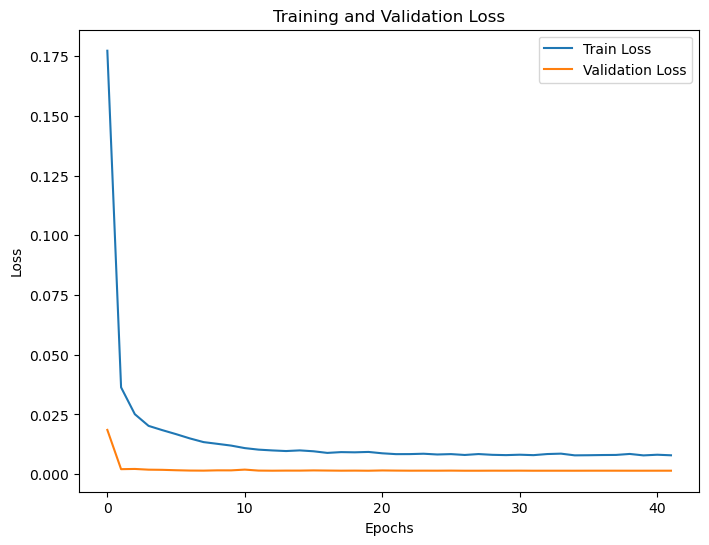

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step


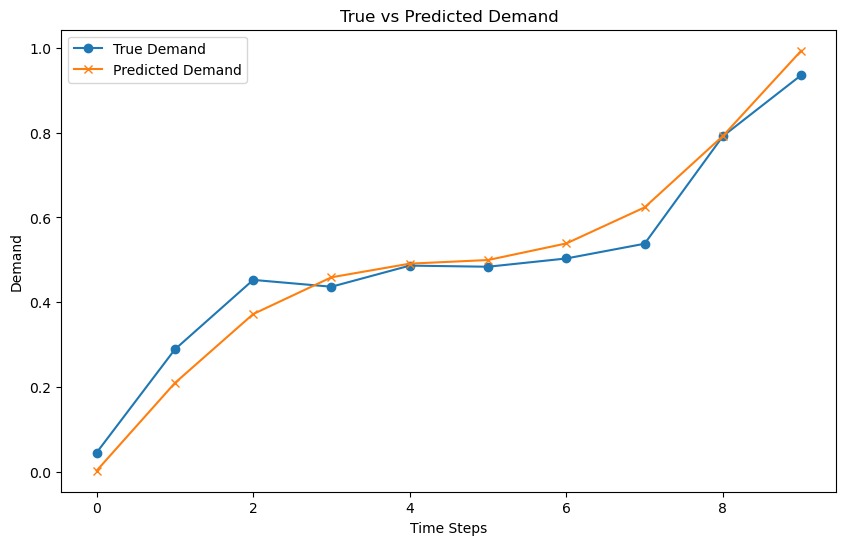

Using cpu device
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.248    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1248     |
|    time_elapsed     | 0        |
|    total_timesteps  | 396      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0167   |
|    n_updates        | 73       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 984      |
|    time_elapsed     | 0        |
|    total_timesteps  | 792      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00129  |
|    n_updates        | 172      |
----------------------------------
----------------------------------
| rollout/            |          |
|  

ValueError: not enough values to unpack (expected 2, got 1)

In [25]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv  # 正确的导入方式

import gymnasium as gym

# 设置随机种子
np.random.seed(42)

# 1. 改进数据生成：添加趋势和周期性
def generate_synthetic_data(num_samples=1000, seq_len=10, num_features=5):
    """生成具有趋势和周期性的时间序列数据"""
    X = np.zeros((num_samples, seq_len, num_features))
    y = np.zeros((num_samples, seq_len, 1))

    for i in range(num_samples):
        trend = np.linspace(0, 1, seq_len)  # 趋势项
        seasonality = 0.3 * np.sin(np.linspace(0, 2 * np.pi, seq_len))  # 周期项
        noise = 0.1 * np.random.randn(seq_len)  # 噪声项

        for j in range(num_features):
            X[i, :, j] = trend + seasonality + noise  # 每个特征加入趋势和周期性

        y[i, :, 0] = trend + 0.5 * seasonality + 0.05 * np.random.randn(seq_len)  # 目标值加入噪声

    return X, y

num_samples = 1000
seq_len = 10
num_features = 5
X, y = generate_synthetic_data(num_samples, seq_len, num_features)

# 2. 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 3. 数据集划分：70%训练集，20%验证集，10%测试集
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# 4. CNN-LSTM模型构建
def build_deep_cnn_lstm_model(input_shape):
    """改进版CNN-LSTM模型"""
    model = Sequential()
    model.add(Input(shape=input_shape))

    # CNN层：增加深度
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    # LSTM层：增加深度和单元数
    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))

    # 输出层
    model.add(Dense(seq_len, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (seq_len, num_features)
model = build_deep_cnn_lstm_model(input_shape)

# 5. CNN-LSTM模型训练
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train.reshape(-1, seq_len),  # 修改y维度用于多步预测
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val.reshape(-1, seq_len)),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 绘制训练过程的损失曲线
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 绘制CNN-LSTM预测结果与真实值对比
y_pred = model.predict(X_test)
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
y_pred_rescaled = scaler_y.inverse_transform(y_pred).reshape(y_test.shape)

plt.figure(figsize=(10, 6))
plt.plot(range(seq_len), y_test_rescaled[0].flatten(), label='True Demand', marker='o')
plt.plot(range(seq_len), y_pred_rescaled[0].flatten(), label='Predicted Demand', marker='x')
plt.title('True vs Predicted Demand')
plt.xlabel('Time Steps')
plt.ylabel('Demand')
plt.legend()
plt.show()

# 9. 改进的自定义Gym环境
class CustomTransportEnv(gym.Env):
    def __init__(self):
        super(CustomTransportEnv, self).__init__()
        self.state_shape = seq_len
        self.action_shape = 5  # 动作数量
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.state_shape,), dtype=np.float32)
        self.action_space = gym.spaces.Discrete(self.action_shape)
        self.reset()

    def reset(self, seed=None, options=None):
        """环境重置，兼容Gymnasium的seed和options参数"""
        super().reset(seed=seed)
        self.current_step = 0
        self.demand = y_test.reshape(-1, seq_len)  # 使用测试集需求作为环境输入
        self.state = self.demand[self.current_step]  # 初始化状态
        self.total_cost = 0  # 累计成本
        return self.state, {}

    def step(self, action):
        """
        环境在当前动作下的动态变化
        :param action: 动作（分配策略）
        :return: (新的状态, 奖励, 是否结束, 附加信息)
        """
        # 定义资源分配逻辑
        resource_allocation = action * 0.2
        demand = np.mean(self.state)
        reward = -np.abs(resource_allocation - demand)  # 越接近需求奖励越高
        self.total_cost += resource_allocation * 10

        # 更新状态
        self.current_step += 1
        done = self.current_step >= len(self.demand) - 1
        if not done:
            self.state = self.demand[self.current_step]
        else:
            self.state = np.zeros_like(self.state)
        return self.state, reward, done, False, {'total_cost': self.total_cost}

# 使用Stable-Baselines3训练DQN
env = DummyVecEnv([lambda: CustomTransportEnv()])
model = DQN('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=5000)

# 测试DQN模型
obs, _ = env.reset()
rewards = []
total_costs = []
for _ in range(10):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = env.step(action)
    rewards.append(reward)
    total_costs.append(info['total_cost'])
    print(f"Action: {action}, Reward: {reward}, Total Cost: {info}")

# 绘制DQN累计奖励和成本曲线
plt.figure(figsize=(10, 6))
plt.plot(rewards, label='Rewards', marker='o')
plt.title('Rewards per Step')
plt.xlabel('Steps')
plt.ylabel('Reward')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(total_costs, label='Total Cost', marker='x')
plt.title('Total Cost per Step')
plt.xlabel('Steps')
plt.ylabel('Cost')
plt.legend()
plt.show()


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.2485 - mae: 0.4498 - val_loss: 0.0161 - val_mae: 0.0932 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0352 - mae: 0.1491 - val_loss: 0.0023 - val_mae: 0.0391 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0232 - mae: 0.1202 - val_loss: 0.0021 - val_mae: 0.0368 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0192 - mae: 0.1092 - val_loss: 0.0025 - val_mae: 0.0404 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0176 - mae: 0.1048 - val_loss: 0.0021 - val_mae: 0.0366 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0151 - mae: 0.0972 - val_loss: 0.0018 - val_mae: 0.0335 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0135 - mae: 0.0910 - val_loss: 0.0021 - val_mae: 0.0368 - learning_rate: 0.0010
Epoch 8/50
22

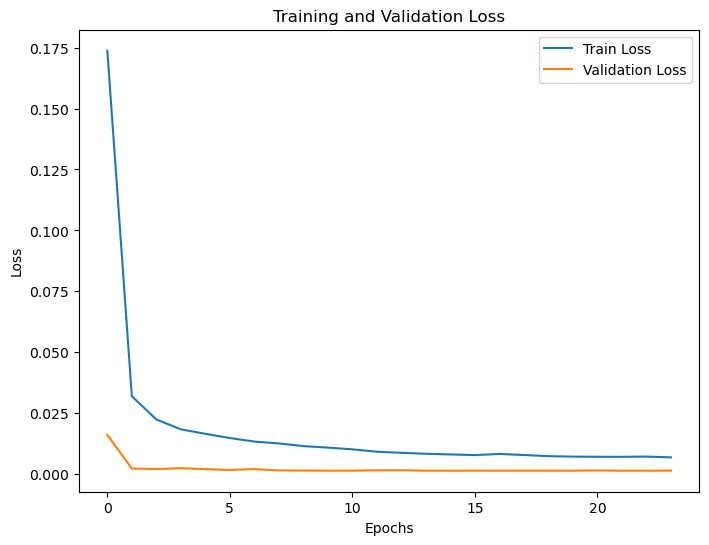

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step


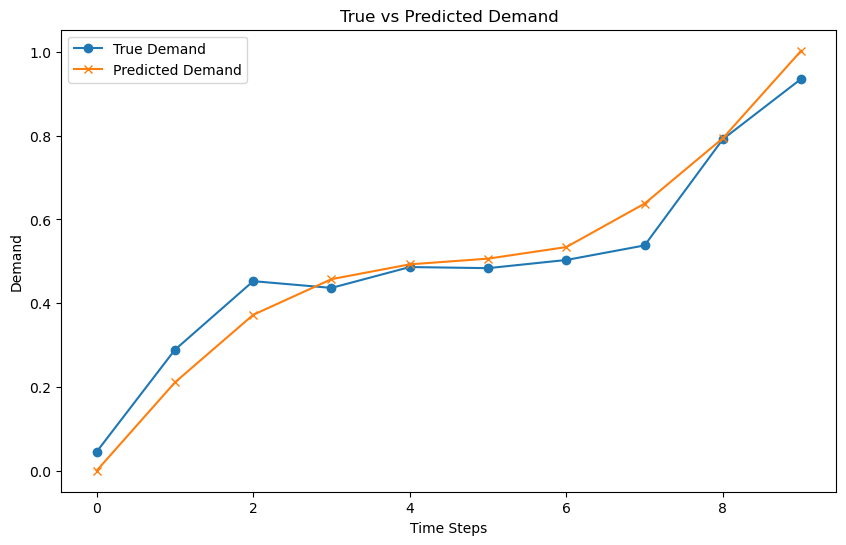

Using cpu device
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.248    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1124     |
|    time_elapsed     | 0        |
|    total_timesteps  | 396      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00259  |
|    n_updates        | 73       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 963      |
|    time_elapsed     | 0        |
|    total_timesteps  | 792      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 9.28e-05 |
|    n_updates        | 172      |
----------------------------------
----------------------------------
| rollout/            |          |
|  

ValueError: not enough values to unpack (expected 2, got 1)

In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv

import gymnasium as gym

# 设置随机种子
np.random.seed(42)

# 数据生成
def generate_synthetic_data(num_samples=1000, seq_len=10, num_features=5):
    X = np.zeros((num_samples, seq_len, num_features))
    y = np.zeros((num_samples, seq_len, 1))

    for i in range(num_samples):
        trend = np.linspace(0, 1, seq_len)
        seasonality = 0.3 * np.sin(np.linspace(0, 2 * np.pi, seq_len))
        noise = 0.1 * np.random.randn(seq_len)

        for j in range(num_features):
            X[i, :, j] = trend + seasonality + noise

        y[i, :, 0] = trend + 0.5 * seasonality + 0.05 * np.random.randn(seq_len)

    return X, y

num_samples = 1000
seq_len = 10
num_features = 5
X, y = generate_synthetic_data(num_samples, seq_len, num_features)

# 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 数据集划分
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# CNN-LSTM模型
def build_deep_cnn_lstm_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))

    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))

    model.add(Dense(seq_len, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (seq_len, num_features)
model = build_deep_cnn_lstm_model(input_shape)

# 模型训练
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train.reshape(-1, seq_len),
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val.reshape(-1, seq_len)),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 绘制损失曲线
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 预测结果与真实值对比
y_pred = model.predict(X_test)
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
y_pred_rescaled = scaler_y.inverse_transform(y_pred).reshape(y_test.shape)

plt.figure(figsize=(10, 6))
plt.plot(range(seq_len), y_test_rescaled[0].flatten(), label='True Demand', marker='o')
plt.plot(range(seq_len), y_pred_rescaled[0].flatten(), label='Predicted Demand', marker='x')
plt.title('True vs Predicted Demand')
plt.xlabel('Time Steps')
plt.ylabel('Demand')
plt.legend()
plt.show()

# 自定义Gym环境
class CustomTransportEnv(gym.Env):
    def __init__(self):
        super(CustomTransportEnv, self).__init__()
        self.state_shape = seq_len
        self.action_shape = 5
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.state_shape,), dtype=np.float32)
        self.action_space = gym.spaces.Discrete(self.action_shape)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.demand = y_test.reshape(-1, seq_len)
        self.state = self.demand[self.current_step]
        self.total_cost = 0
        return self.state, {}

    def step(self, action):
        resource_allocation = action * 0.2
        demand = np.mean(self.state)
        reward = -np.abs(resource_allocation - demand)
        self.total_cost += resource_allocation * 10

        self.current_step += 1
        done = self.current_step >= len(self.demand) - 1
        truncated = done
        if not done:
            self.state = self.demand[self.current_step]
        else:
            self.state = np.zeros_like(self.state)
        return self.state, reward, done, truncated, {'total_cost': self.total_cost}

# 使用DQN训练
env = DummyVecEnv([lambda: CustomTransportEnv()])
model = DQN('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=5000)

# 测试DQN模型
obs, info = env.reset()
rewards = []
total_costs = []
for _ in range(10):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
    rewards.append(reward[0])
    total_costs.append(info[0]['total_cost'])
    print(f"Action: {action}, Reward: {reward[0]}, Total Cost: {info[0]['total_cost']}")

# 绘制奖励和成本曲线
plt.figure(figsize=(10, 6))
plt.plot(rewards, label='Rewards', marker='o')
plt.title('Rewards per Step')
plt.xlabel('Steps')
plt.ylabel('Reward')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(total_costs, label='Total Cost', marker='x')
plt.title('Total Cost per Step')
plt.xlabel('Steps')
plt.ylabel('Cost')
plt.legend()
plt.show()


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.2304 - mae: 0.4307 - val_loss: 0.0088 - val_mae: 0.0789 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0304 - mae: 0.1375 - val_loss: 0.0020 - val_mae: 0.0363 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0222 - mae: 0.1164 - val_loss: 0.0023 - val_mae: 0.0384 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0177 - mae: 0.1047 - val_loss: 0.0017 - val_mae: 0.0326 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0161 - mae: 0.1001 - val_loss: 0.0016 - val_mae: 0.0323 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0155 - mae: 0.0984 - val_loss: 0.0016 - val_mae: 0.0323 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0137 - mae: 0.0923 - val_loss: 0.0015 - val_mae: 0.0310 - learning_rate: 0.0010
Epoch 8/50
22

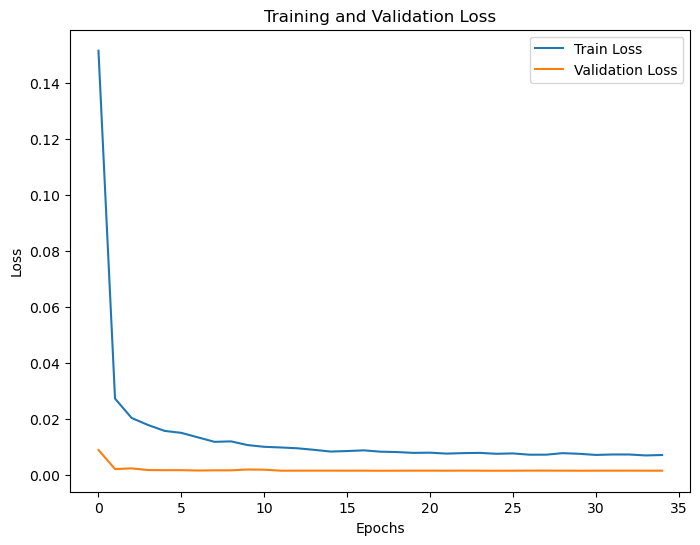

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step


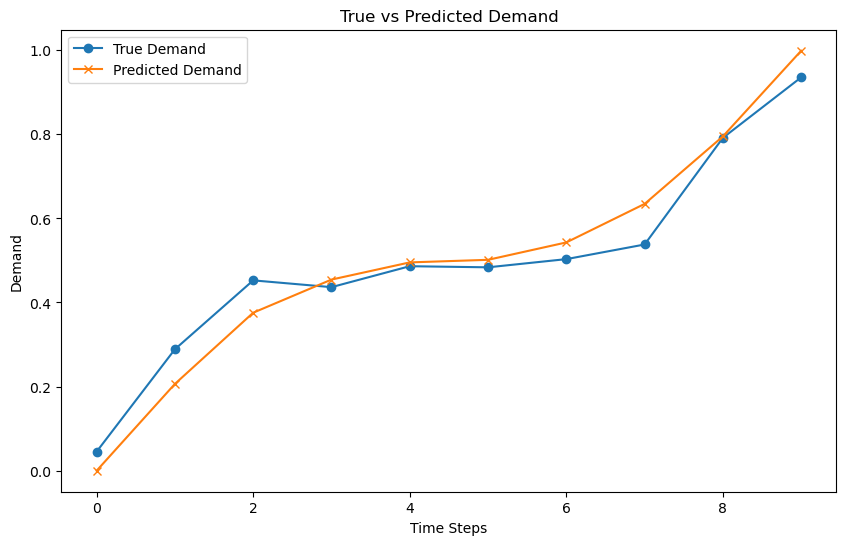

In [2]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium as gym

# 设置随机种子
np.random.seed(42)

# 数据生成
def generate_synthetic_data(num_samples=1000, seq_len=10, num_features=5):
    X = np.zeros((num_samples, seq_len, num_features))
    y = np.zeros((num_samples, seq_len, 1))

    for i in range(num_samples):
        trend = np.linspace(0, 1, seq_len)
        seasonality = 0.3 * np.sin(np.linspace(0, 2 * np.pi, seq_len))
        noise = 0.1 * np.random.randn(seq_len)

        for j in range(num_features):
            X[i, :, j] = trend + seasonality + noise

        y[i, :, 0] = trend + 0.5 * seasonality + 0.05 * np.random.randn(seq_len)

    return X, y

num_samples = 1000
seq_len = 10
num_features = 5
X, y = generate_synthetic_data(num_samples, seq_len, num_features)

# 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 数据集划分
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# CNN-LSTM模型
def build_deep_cnn_lstm_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))

    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))

    model.add(Dense(seq_len, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (seq_len, num_features)
model = build_deep_cnn_lstm_model(input_shape)

# 模型训练
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train.reshape(-1, seq_len),
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val.reshape(-1, seq_len)),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 绘制损失曲线
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 预测结果与真实值对比
y_pred = model.predict(X_test)
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
y_pred_rescaled = scaler_y.inverse_transform(y_pred).reshape(y_test.shape)

plt.figure(figsize=(10, 6))
plt.plot(range(seq_len), y_test_rescaled[0].flatten(), label='True Demand', marker='o')
plt.plot(range(seq_len), y_pred_rescaled[0].flatten(), label='Predicted Demand', marker='x')
plt.title('True vs Predicted Demand')
plt.xlabel('Time Steps')
plt.ylabel('Demand')
plt.legend()
plt.show()

# 自定义Gym环境
class CustomTransportEnv(gym.Env):
    def __init__(self):
        super(CustomTransportEnv, self).__init__()
        self.state_shape = seq_len
        self.action_shape = 5
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.state_shape,), dtype=np.float32)
        self.action_space = gym.spaces.Discrete(self.action_shape)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.demand = y_test.reshape(-1, seq_len)
        self.state = self.demand[self.current_step]
        self.total_cost


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.2507 - mae: 0.4512 - val_loss: 0.0094 - val_mae: 0.0813 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0408 - mae: 0.1591 - val_loss: 0.0039 - val_mae: 0.0508 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0257 - mae: 0.1265 - val_loss: 0.0022 - val_mae: 0.0378 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0228 - mae: 0.1182 - val_loss: 0.0017 - val_mae: 0.0332 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0187 - mae: 0.1076 - val_loss: 0.0015 - val_mae: 0.0315 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0162 - mae: 0.1003 - val_loss: 0.0016 - val_mae: 0.0320 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0137 - mae: 0.0923 - val_loss: 0.0016 - val_mae: 0.0319 - learning_rate: 0.0010
Epoch 8/50
22

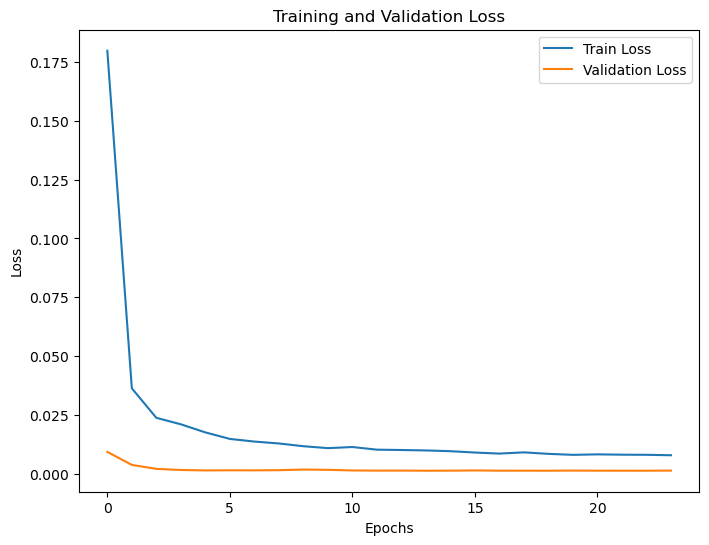

1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 371ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000019345E4EC00> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step


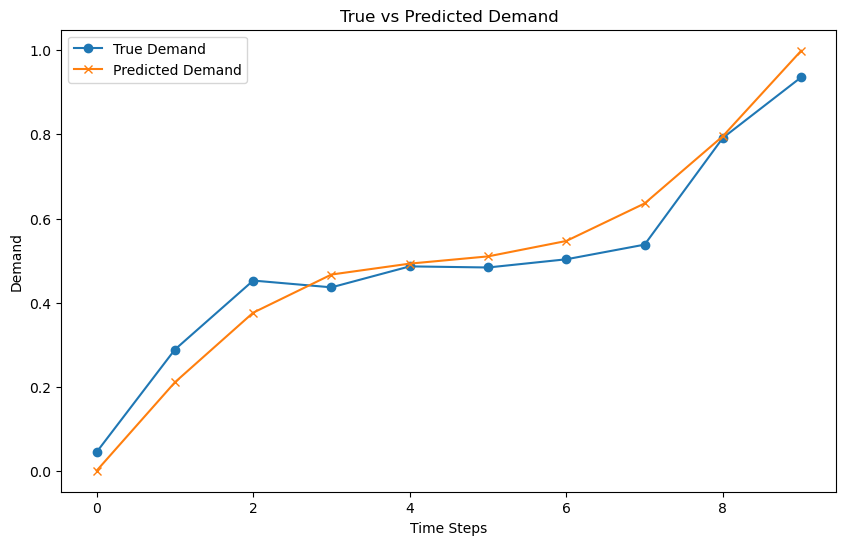

Using cpu device
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.248    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1128     |
|    time_elapsed     | 0        |
|    total_timesteps  | 396      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0111   |
|    n_updates        | 73       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1023     |
|    time_elapsed     | 0        |
|    total_timesteps  | 792      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000617 |
|    n_updates        | 172      |
----------------------------------
----------------------------------
| rollout/            |          |
|  

ValueError: not enough values to unpack (expected 2, got 1)

In [3]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium as gym

# 设置随机种子
np.random.seed(42)

# 数据生成函数
def generate_synthetic_data(num_samples=1000, seq_len=10, num_features=5):
    X = np.zeros((num_samples, seq_len, num_features))
    y = np.zeros((num_samples, seq_len, 1))

    for i in range(num_samples):
        trend = np.linspace(0, 1, seq_len)
        seasonality = 0.3 * np.sin(np.linspace(0, 2 * np.pi, seq_len))
        noise = 0.1 * np.random.randn(seq_len)

        for j in range(num_features):
            X[i, :, j] = trend + seasonality + noise

        y[i, :, 0] = trend + 0.5 * seasonality + 0.05 * np.random.randn(seq_len)

    return X, y

# 数据生成
num_samples = 1000
seq_len = 10
num_features = 5
X, y = generate_synthetic_data(num_samples, seq_len, num_features)

# 数据标准化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(y.shape)

# 数据集划分
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.2)

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y_scaled[:train_size], y_scaled[train_size:train_size+val_size], y_scaled[train_size+val_size:]

# CNN-LSTM模型
def build_deep_cnn_lstm_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(units=128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(seq_len, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (seq_len, num_features)
model = build_deep_cnn_lstm_model(input_shape)

# 模型训练
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train.reshape(-1, seq_len),
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val.reshape(-1, seq_len)),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 绘制损失曲线
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 预测结果与真实值对比
y_pred = model.predict(X_test)
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
y_pred_rescaled = scaler_y.inverse_transform(y_pred).reshape(y_test.shape)

plt.figure(figsize=(10, 6))
plt.plot(range(seq_len), y_test_rescaled[0].flatten(), label='True Demand', marker='o')
plt.plot(range(seq_len), y_pred_rescaled[0].flatten(), label='Predicted Demand', marker='x')
plt.title('True vs Predicted Demand')
plt.xlabel('Time Steps')
plt.ylabel('Demand')
plt.legend()
plt.show()

# 自定义Gym环境
class CustomTransportEnv(gym.Env):
    def __init__(self):
        super(CustomTransportEnv, self).__init__()
        self.state_shape = seq_len
        self.action_shape = 5
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.state_shape,), dtype=np.float32)
        self.action_space = gym.spaces.Discrete(self.action_shape)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.demand = y_test.reshape(-1, seq_len)
        self.state = self.demand[self.current_step]
        self.total_cost = 0
        return self.state, {}

    def step(self, action):
        resource_allocation = action * 0.2
        demand = np.mean(self.state)
        reward = -np.abs(resource_allocation - demand)
        self.total_cost += resource_allocation * 10
        self.current_step += 1
        done = self.current_step >= len(self.demand) - 1
        truncated = done
        if not done:
            self.state = self.demand[self.current_step]
        else:
            self.state = np.zeros_like(self.state)
        return self.state, reward, done, truncated, {'total_cost': self.total_cost}

# 使用DQN训练
env = DummyVecEnv([lambda: CustomTransportEnv()])
model = DQN('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=5000)

# 测试DQN模型
obs, info = env.reset()
rewards = []
total_costs = []
for _ in range(10):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
    rewards.append(reward[0])
    total_costs.append(info[0]['total_cost'])
    print(f"Action: {action}, Reward: {reward[0]}, Total Cost: {info[0]['total_cost']}")

# 绘制奖励和成本曲线
plt.figure(figsize=(10, 6))
plt.plot(rewards, label='Rewards', marker='o')
plt.title('Rewards per Step')
plt.xlabel('Steps')
plt.ylabel('Reward')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(total_costs, label='Total Cost', marker='x')
plt.title('Total Cost per Step')
plt.xlabel('Steps')
plt.ylabel('Cost')
plt.legend()
plt.show()
